In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as smp
from sympy.polys.polyfuncs import interpolate
from matplotlib.pyplot import figure
from scipy.interpolate import CubicSpline
from scipy.interpolate import PchipInterpolator
import ipywidgets as widgets
from ipywidgets import interact
from scipy.interpolate import UnivariateSpline

In [2]:
data = np.load("data/data_interp.npz")

# Задача 1. Вводное задание.

Вектора х1 и у1 из архива дают значения некоторой функции $f(x)$. Постройте на графике, используя библиотечные функции:

## (a) Интерполяционный Лагранжев многочлен.

In [3]:
x1 = data['x1']
y1 = data['y1']

In [4]:
t = smp.Symbol('t')

points = [(x1[i], y1[i]) for i in range(len(x1))]

L = smp.lambdify(t, interpolate(points, t), 'numpy')

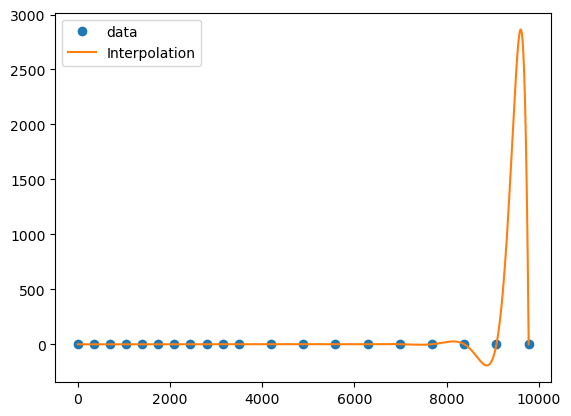

In [5]:
xnew = np.linspace(min(x1), max(x1), 1000)

plt.plot(x1, y1, 'o', xnew, L(xnew), '-')
plt.legend(['data', 'Interpolation'], loc = 'best')
plt.show()

## (b) Интерполяционный кубический сплайн (CubicSpline).

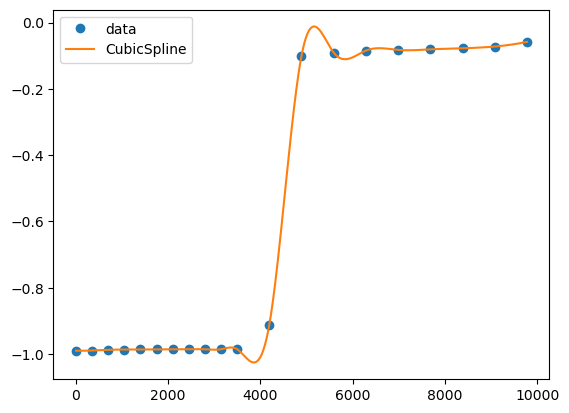

In [6]:
Cubic = CubicSpline(x1, y1)

plt.plot(x1, y1, 'o', xnew, Cubic(xnew), '-')
plt.legend(['data', 'CubicSpline'], loc = 'best')
plt.show()

## (c) Монотонный кубический интерполянт (PchipInterpolator).

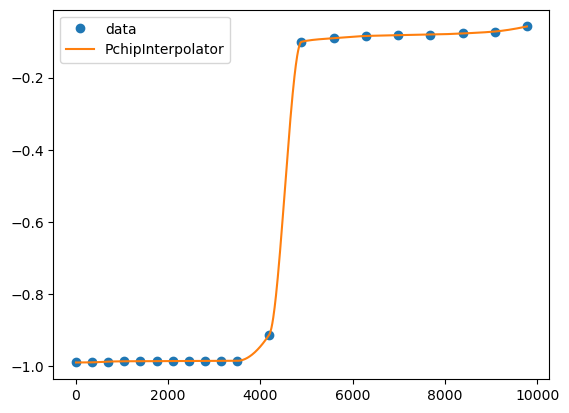

In [7]:
Pchip = PchipInterpolator(x1, y1)

plt.plot(x1, y1, 'o', xnew, Pchip(xnew), '-')
plt.legend(['data', 'PchipInterpolator'], loc = 'best')
plt.show()

## (d) Аппроксимацию полиномами, используя функции np. polyfit и np.polyval.

In [8]:
def draw_plot(power):
    polynom = np.polyfit(x1, y1, power)
    
    def eval(x):
        return np.polyval(polynom, x)
    
    plt.plot(x1, y1, 'o', xnew, eval(xnew), '-')
    plt.legend(['data', 'polyfit'], loc = 'best')
    plt.show()

interact(draw_plot, power=widgets.IntSlider(min=1, max=20, step=1, value=5))

interactive(children=(IntSlider(value=5, description='power', max=20, min=1), Output()), _dom_classes=('widget…

<function __main__.draw_plot(power)>

## Задача 2. Интерполяция полиномом Лагранжа.

Допишите класс, который конструирует интерполяционный полином Лагранжа, проходящий через точки, заданные как xk и yk.

In [9]:
import numpy as np

class LagrangeInterpolator:
    """Lagrange interpolating polynomial.

    Given a set of pairs ``(x_k, y_k)``, construct
    a Lagrange polynomial ``f(x)``, such that

    .. math::

        f(x_k) = y_k   for k =0, ..., n-1

    Parameters
    ----------
    xk : array_like, shape(n,)
        Abscissas
    yk : array_like, shape(n,)
        Ordinates

    Attributes
    ----------
    __call__

    """
    def __init__(self, xk, yk):
        self.xk = np.asarray(xk, dtype=float)
        self.yk = np.asarray(yk, dtype=float)
        
    def __call__(self, x):
        """Evaluate the interpolator at a given point.

        Parameters
        ----------
        x : float

        Returns
        -------
        the value of the interpolator at ``x``.
        """
        sum = 0
    
        for i in range(len(self.xk)):
            temp = 1
            
            for j in range(len(self.xk)):
                if i == j:
                    continue
                temp *= (x - self.xk[j]) / (self.xk[i] - self.xk[j])
            
            sum += temp * self.yk[i]
        
        return sum

In [10]:
def runge_func(x, a=25):
    return 1.0 / (1.0 + a*x**2)

xx = np.linspace(-2, 2, 21)
yy = runge_func(xx)

lagr = LagrangeInterpolator(xx, yy)

from numpy.testing import assert_allclose

assert_allclose(yy,
                [lagr(xval) for xval in xx],
                atol=1e-14)

## Задача 3. Феномен Рунге

Рассмотрим функцию Рунге, $y = 1/(1+ 25x^2)$. 
Интерполируйте эту функцию на интервале $x \in [-2, 2]$, используя полином Лагранжа с $m = 3, 5, 7, 11$.
Используйте равномерную сетку. Нарисуйте результат интерполяции вместе с исходной функцией на одном графике.

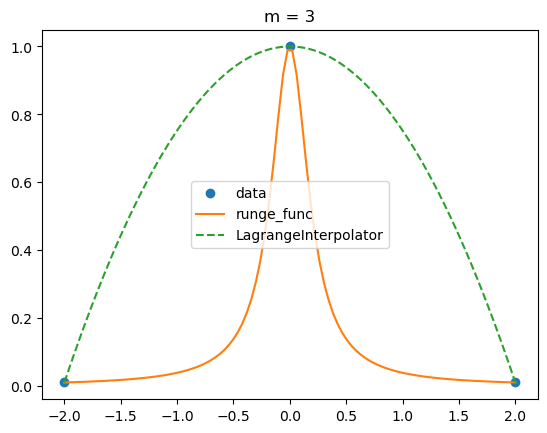

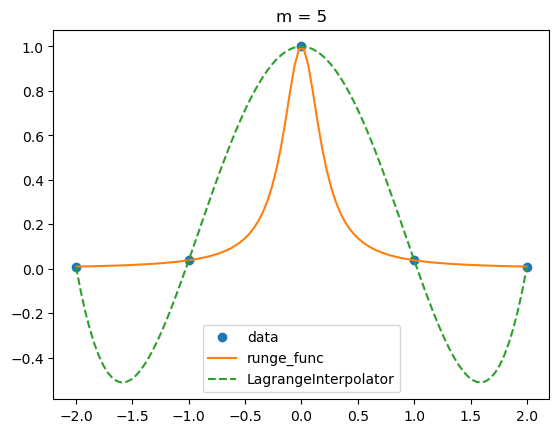

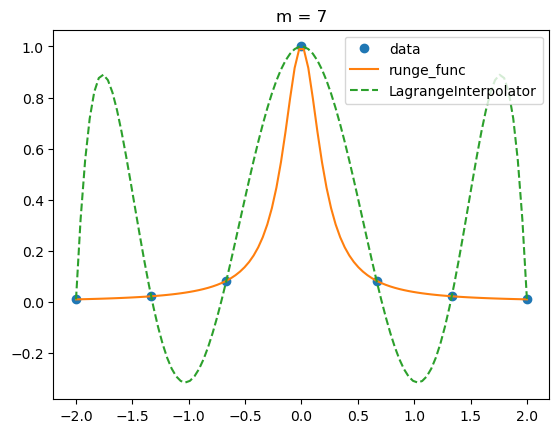

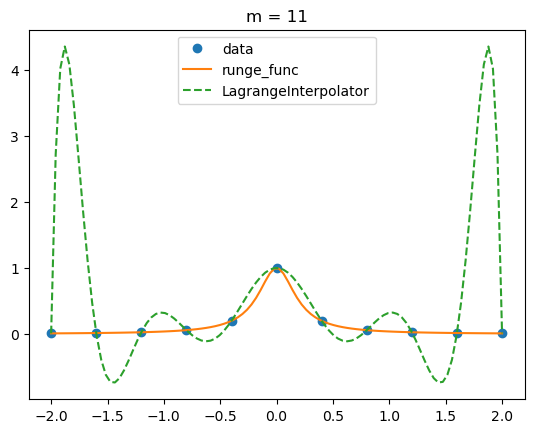

In [11]:
m = [3, 5, 7, 11]

for m_val in m:
    x_train = np.linspace(-2, 2, m_val)
    y_train = runge_func(x_train)
    
    lagr = LagrangeInterpolator(x_train, y_train)
    
    x_dense = np.linspace(-2, 2, 100)
    y_actual = runge_func(x_dense)
    y_lagr = lagr(x_dense)
    
    plt.plot(x_train, y_train, 'o', x_dense, y_actual, '-', x_dense, y_lagr, '--')
    plt.title(f'm = {m_val}')
    plt.legend(['data', 'runge_func', 'LagrangeInterpolator'], loc = 'best')
    plt.show()

Допишите функцию, которая возвращает узлы Чебышева.

In [12]:
def cheb_nodes(n, a=-1, b=1):
    r"""Chebyshev nodes of degree $n$ on $[a, b]$
    """
    
    out = np.empty(n)
    
    for i in range(n):
        phi = ((2*(n-i) - 1)/(2*n))*np.pi
               
        out[i] = 0.5*(a+b) + 0.5*(b-a)*np.cos(phi)
    
    return out

In [13]:
nodes_11 = cheb_nodes(11)
nodes_11 = np.asarray(nodes_11)
assert (nodes_11[1:] > nodes_11[:-1]).all()

from scipy.special import roots_chebyt
nodes, weights = roots_chebyt(5)


assert_allclose(cheb_nodes(5),
                nodes, atol=1e-14)

assert_allclose(cheb_nodes(5, a=-1, b=3),
                nodes*2 + 1, atol=1e-14)

Повторите интерполяцию Лагранжа функции Рунге с помощью узлов Чебышева. Постройте интерполянты. Также постройте интерполяцию кубическим сплайном тех же данных (scipy.interpolate.CubicSpline). Сравните величину явления Рунге для равномерной сетки и сетки Чебышева. Демонстрирует ли интерполяция сплайнами феномен Рунге?

In [14]:
cheb = lambda n: cheb_nodes(n, -2, 2)
linsp = lambda n: np.linspace(-2, 2, n)
lag_int = lambda x, y: LagrangeInterpolator(x, y)
cub_int = lambda x, y: CubicSpline(x, y)

def draw_plot(n, func, nodes, interp, title, int_name, func_name):
        x_train = nodes(n)
        y_train = func(x_train)
        
        plt.tight_layout()
        interpolator = interp(x_train, y_train)

        x_dense = np.linspace(-2, 2, 100)
        y_actual = func(x_dense)
        y_int = interpolator(x_dense)

        plt.plot(x_train, y_train, 'o', x_dense, y_actual, '-', x_dense, y_int, '--')
        plt.title(title)
        plt.legend(['data', func_name, int_name], loc = 'best')
        
       
        plt.show()

interact(lambda n : draw_plot( \
    n, runge_func, cheb, lag_int, "LagrangeInterpolator with cheb_nodes", "LagrangeInterpolator", 'runge_func' \
                             ), n=widgets.IntSlider(min=1, max=20, step=1, value=11))

interact(lambda n : draw_plot( \
    n, runge_func, linsp, cub_int, "CubicSpline with linspace", "CubicSpline", 'runge_func' \
                             ), n=widgets.IntSlider(min=1, max=20, step=1, value=11))

interact(lambda n : draw_plot( \
    n, runge_func, cheb, cub_int, "CubicSpline with cheb_nodes", "CubicSpline", 'runge_func' \
                             ), n=widgets.IntSlider(min=1, max=20, step=1, value=11))


interactive(children=(IntSlider(value=11, description='n', max=20, min=1), Output()), _dom_classes=('widget-in…

interactive(children=(IntSlider(value=11, description='n', max=20, min=1), Output()), _dom_classes=('widget-in…

interactive(children=(IntSlider(value=11, description='n', max=20, min=1), Output()), _dom_classes=('widget-in…

<function __main__.<lambda>(n)>

Другим известным трудным тестом для интерполяции является следующая периодическая функция:

$ u(x) = \frac{\sqrt{\varepsilon(2+\varepsilon)}}{2\pi(1+\varepsilon - cosx)}, \quad -\pi \leq x \leq \pi, \quad \varepsilon = 0.21$|

Проведите аналогичные вычисления и постройте графики для неё.


In [15]:
e = 0.21

def u(x):
    return np.sqrt(e*(2+e))/(2*np.pi*(1+e-np.cos(x)))

interact(lambda n : draw_plot( \
    n, u, linsp, lag_int, "u(x) LagrangeInterpolator with linspace", "LagrangeInterpolator", 'u(x)' \
                             ), n=widgets.IntSlider(min=1, max=20, step=1, value=11))

interact(lambda n : draw_plot( \
    n, u, cheb, lag_int, "u(x) LagrangeInterpolator with cheb_nodes", "LagrangeInterpolator", 'u(x)' \
                             ), n=widgets.IntSlider(min=1, max=20, step=1, value=11))

interact(lambda n : draw_plot( \
    n, u, linsp, cub_int, "CubicSpline with linspace", "CubicSpline", 'u(x)' \
                             ), n=widgets.IntSlider(min=1, max=20, step=1, value=11))

interact(lambda n : draw_plot( \
    n, u, cheb, cub_int, "CubicSpline with cheb_nodes", "CubicSpline", 'u(x)' \
                             ), n=widgets.IntSlider(min=1, max=20, step=1, value=11))


interactive(children=(IntSlider(value=11, description='n', max=20, min=1), Output()), _dom_classes=('widget-in…

interactive(children=(IntSlider(value=11, description='n', max=20, min=1), Output()), _dom_classes=('widget-in…

interactive(children=(IntSlider(value=11, description='n', max=20, min=1), Output()), _dom_classes=('widget-in…

interactive(children=(IntSlider(value=11, description='n', max=20, min=1), Output()), _dom_classes=('widget-in…

<function __main__.<lambda>(n)>

## Задача 4. UnivariateSpline.

Прочитать документацию к UnivariateSpline и определить оптимальное значение для параметра сглаживания s, учитывая, что шум был задан в виде $u_i = \,\, ... \, + \, 0.5 \xi_i, \quad \xi_i \sim \mathcal{N}(0, 1)$. Экспериментально проверить оптимальность этого значения для какой-либо функции


If the weights represent the inverse of the standard-deviation of y, then a good s value should be found in the range (m-sqrt(2*m),m+sqrt(2*m)) where m is the number of datapoints in x, y, and w. 

$ s \in (m-2, m+2) \quad s \approx len(x)$

In [16]:
xi = np.random.normal(0, 1, len(x1))

def on_change(s, a, b, c, draw=True, update_xi = True):
    global xi
    
    def sol(t):
        return a/(np.cosh(0.0001*b*(np.abs(t) + c))**2)
    
    if update_xi:
        xi = np.random.normal(0, 1, len(x1))
    
    y = sol(x1) + xi

    spline = UnivariateSpline(x1, y, s=s)
    
    rmse = np.sqrt(np.mean((spline(xnew) - sol(xnew)) ** 2))
    
    if draw:
        plt.plot(x1, y, 'o', xnew, spline(xnew), '-', xnew, sol(xnew), '--')
        plt.legend(['data', 'UnivariateSpline', 'actual function'], loc = 'best')
        plt.show()
        
    return rmse

In [17]:
total = count = 0

for i in range(100):
    for a in range(10, 20):
        for b in range(3, 7):
            for c in range(-9000, 0, 1000):
                errors = []
                s_vals = []

                for s in range(10, 30):
                    errors.append(on_change(s, a, b, c, False, s==10))
                    s_vals.append(s)

                count += 1
                total += s_vals[np.argmin(errors)]

print('Average best s=', total/count)

Average best s= 14.181972222222223


In [18]:
interact(on_change, s=widgets.IntSlider(min=1, max=50, step=1, value=len(x1)), \
         a=widgets.IntSlider(min=1, max=100, step=1, value=10), \
         b=widgets.IntSlider(min=0, max=10, step=1, value=5), \
         c=widgets.IntSlider(min=-10000, max=10000, step=100, value=-5000))

interactive(children=(IntSlider(value=20, description='s', max=50, min=1), IntSlider(value=10, description='a'…

<function __main__.on_change(s, a, b, c, draw=True, update_xi=True)>

## Задача 5. Производная и шум

Цель - найти производную следующей таблично-заданной функции с шумом. Всего есть 1000 узлов. Генерировать новые точки нельзя.

$ u(t) = \frac{200}{1+\frac{t}{200}}(0.5 + 0.5cos(0.04t)) + noise $

1. Сделайте это через конечные разности, используя минимальное даное расстояние между точками. Вспоминаем семинар 1.

In [19]:
def u(t):
    return 200*(0.5 + 0.5*np.cos(0.04*t))/(1+t/200)

def ut(t):
    return (1 + np.cos(0.04*t) - 0.04*(200 + t)*np.sin(0.04*t))/(2*(1+t/200)**2)
                                           
                                           
x_vals = np.linspace(0, 1000, 1000)                               
noise = np.random.normal(0, 0.5, len(x_vals))

u_vals = u(x_vals) + noise
ut_vals = ut(x_vals)

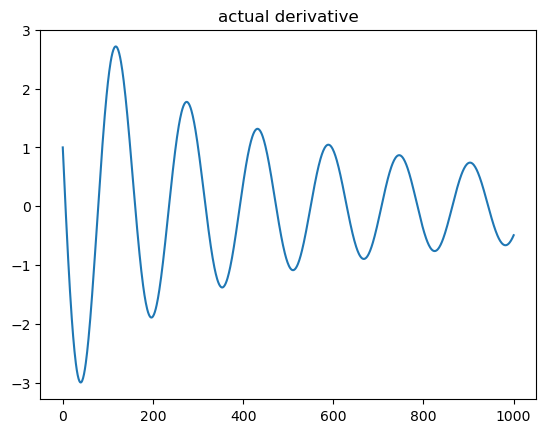

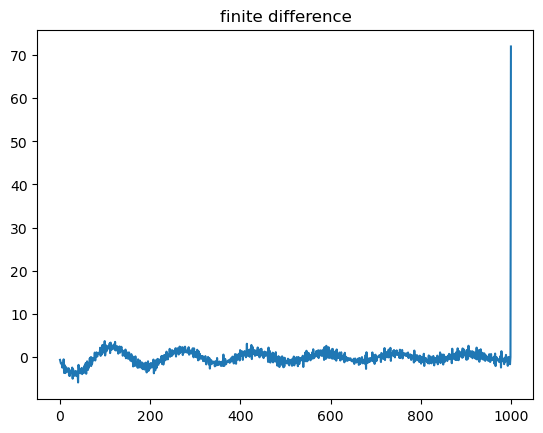

In [20]:
der1 = np.empty(len(x_vals))

for i in range(1, len(x_vals)):
    der1[i-1] = (u_vals[i] - u_vals[i-1]) / (x_vals[i] - x_vals[i-1])

plt.plot(x_vals, ut_vals)
plt.title('actual derivative')
plt.show()
    
plt.plot(x_vals, der1)
plt.title('finite difference')
plt.show()

2. Сделайте это через оптимальный шаг численного дифференциирования. То есть, при оценке производной надо брать несоседние точки исходя из погрешностей 
. Какой шаг надо брать по индексам точек?

$ h* = 2\sqrt{\frac{\Delta f}{M_2}}; \quad \Delta f = 1, u_{tt} \approx \frac{0.16}{1+t/200)}cos(0.04t), M_2 = 0.2; \quad h* = 2\sqrt{5} \approx 4 $

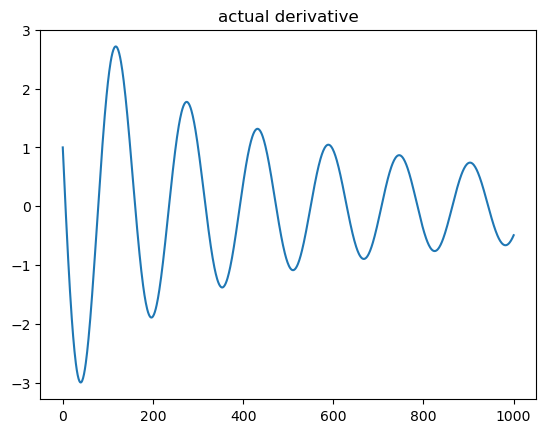

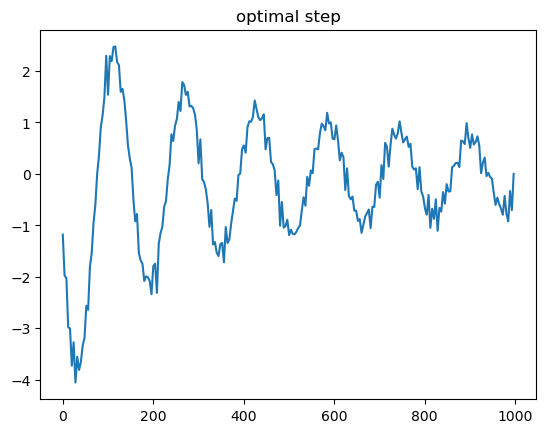

In [21]:
newx = x_vals[::4]

der2 = np.empty(len(newx))

for i in range(4, len(x_vals), 4):
    der2[int(i/4) - 1] = (u_vals[i] - u_vals[i-4]) / (x_vals[i] - x_vals[i-4])

plt.plot(x_vals, ut_vals)
plt.title('actual derivative')
plt.show()
    
plt.plot(newx, der2)
plt.title('optimal step')
plt.show()

3. Сделайте это через UnivariateSpline, используя метод .derivative() - он аналитически дифференциирует объект сплайна и выдаёт также объект сплайна (т.е. можем обращаться к нему как к функции). Не забывайте корректно определить параметр s.

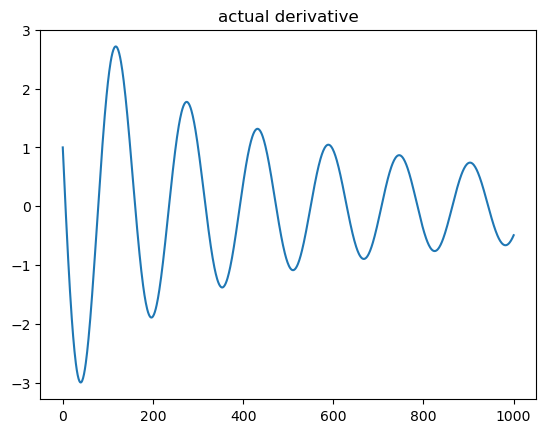

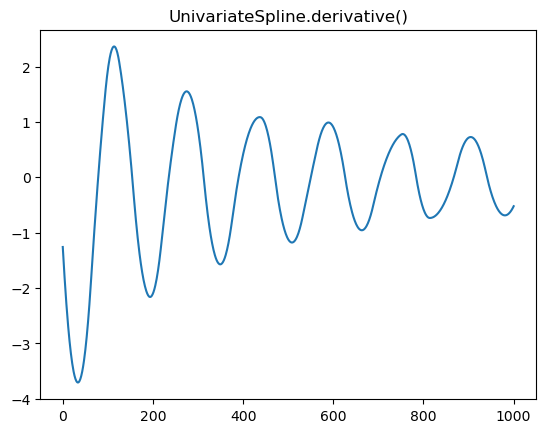

In [22]:
uspl = UnivariateSpline(x_vals, u_vals, s=len(x_vals))

der3 = uspl.derivative()

plt.plot(x_vals, ut_vals)
plt.title('actual derivative')
plt.show()
    
plt.plot(x_vals, der3(x_vals))
plt.title('UnivariateSpline.derivative()')
plt.show()

In [23]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

print(rmse(u_vals, der1))
print(rmse(u_vals[::4], der2))
print(rmse(u_vals, der3(x_vals)))

51.90647221700195
52.497100121911885
51.85206169754249
